# 👩‍💻 Forecasting Retail Sales Using Facebook Prophet
## 📋 Overview
In this lab, you'll apply Facebook Prophet to forecast retail sales data, a crucial task for businesses optimizing inventory and marketing strategies. You'll prepare time series data, build and configure a Prophet model with appropriate seasonality settings, generate forecasts for future periods, and evaluate the model's performance. By the end, you'll have a complete sales forecasting pipeline that provides actionable business insights.
## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Prepare time series data specifically for Prophet's required format
- Configure and train a Prophet model with appropriate seasonality settings
- Generate and visualize sales forecasts including confidence intervals
- Interpret forecast components (trend, seasonality, holidays) for business insights
- Evaluate forecast performance using appropriate metrics

## 🚀 Starting Point
Access the starter code by running the cells below. The lab uses a retail dataset containing historical sales information that we'll use for forecasting.

Required tools/setup:

- Python 3.x
- pandas, numpy, matplotlib
- prophet (Facebook Prophet)
- scikit-learn (for evaluation metrics)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install -qq plotly
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
data = pd.read_csv('stores_sales_forecasting.csv', encoding='latin-1')
print("Dataset preview:")
display(data.head())
print("\nDataset shape:", data.shape)

Dataset preview:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092



Dataset shape: (2121, 21)


## Task 1: Prepare Time Series Data for Prophet
**Context:** In retail analytics, we need to transform raw sales data into a format suitable for time series forecasting. Prophet requires a specific data structure with date ('ds') and target ('y') columns.

**Steps:**

1. Convert 'Order Date' and 'Ship Date' columns to datetime using pandas' `to_datetime()` function.


2. Aggregate sales by date to create a daily time series:

    - Use `groupby()` on 'Order Date' and sum the 'Sales' column
    - Reset the index to convert the grouped data back to a DataFrame
    - Rename the columns to match Prophet's required format ('ds' for date, 'y' for target)


3. Examine the prepared time series data to ensure it's ready for modeling.

In [2]:
# Your code for converting dates to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

# Your code for aggregating sales by date
daily_sales = data.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['ds', 'y']  # Rename for Prophet compatibility

# Print the prepared data
print("\nDaily sales data:")
display(daily_sales.head())


Daily sales data:


,ds,y
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-10,51.940
3,2014-01-11,9.940
4,2014-01-13,879.939


**💡 Tip:** Make sure your date column is sorted in ascending order for Prophet to work correctly.

**⚙️ Test Your Work:**

- The resulting DataFrame should have exactly two columns named 'ds' and 'y'
- Print the first 5 rows to confirm the structure is correct
- Expected output: A DataFrame with dates in the 'ds' column and daily sales totals in the 'y' column

## Task 2: Visualize the Time Series Data
**Context:** Before building a forecasting model, it's important to understand the patterns in your data visually to identify trends, seasonality, and potential outliers.

**Steps:**

1. Create a figure with appropriate dimensions using `plt.figure(figsize=(width, height)).`


2. Plot the time series data:

    - Use the 'ds' column for x-axis (dates)
    - Use the 'y' column for y-axis (sales)
    - Add appropriate title and axis labels


3. Display the plot to examine patterns in the sales data.

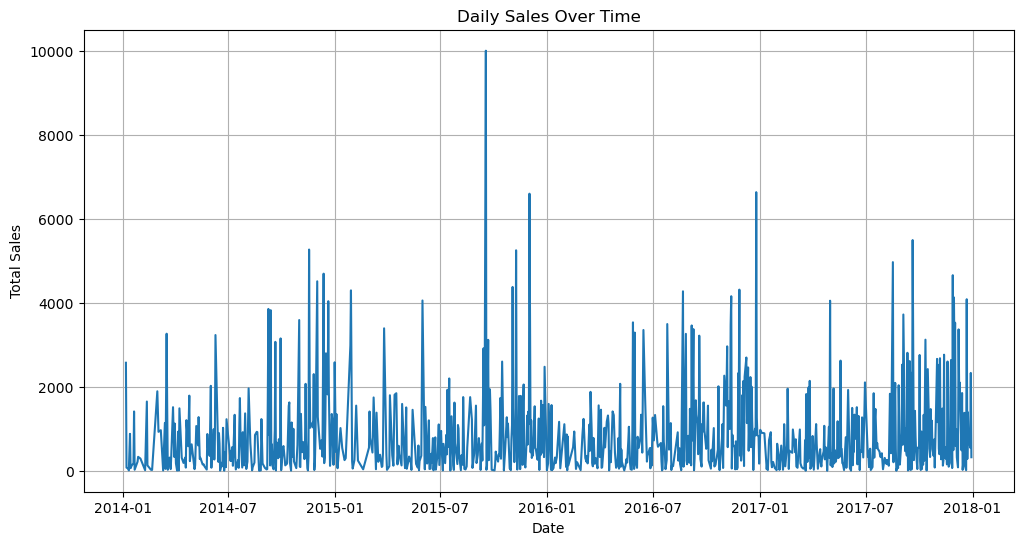

In [3]:
# Your code for creating the time series plot
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['ds'], daily_sales['y'])
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)

# Show the plot
plt.show()

**💡 Tip:** Look for weekly patterns, yearly seasonality, and any unusual spikes or dips that might affect your forecast.

**⚙️ Test Your Work:**

- A line plot should appear showing sales over time
- The plot should have labeled axes and a title
- Observe if there are clear seasonal patterns or trends

## Task 3: Build and Fit the Prophet Model
**Context:** Prophet is designed to handle multiple seasonalities and holidays, making it ideal for retail sales forecasting where these factors significantly impact sales.

**Steps:**

1. Create a Prophet model with appropriate parameters:

    - Set `yearly_seasonality=True` to capture annual patterns
    - Set `weekly_seasonality=True` for weekly patterns
    - Set `daily_seasonality=False` unless you have intra-day data
    - Set `seasonality_mode='multiplicative'` as retail often has multiplicative seasonality


2. Add US holidays to the model using `add_country_holidays()` to account for holiday effects on sales.


3. Fit the model to your prepared time series data using the `fit()` method.

In [4]:
# Your code for creating the Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # Retail often has multiplicative seasonality

    changepoint_prior_scale=0.01, # Experiment with values like 0.005, 0.1, 0.5

    seasonality_prior_scale=12.0, # Experiment with values like 5.0, 20.0

    holidays_prior_scale=10.0, # Experiment with values like 5.0, 20.0

    interval_width=0.80, # Set to 0.95 for wider, 95% confidence intervals
)

# Your code for adding holidays
model.add_country_holidays(country_name='US')

# Your code for fitting the model
model.fit(daily_sales)

08:54:28 - cmdstanpy - INFO - Chain [1] start processing
08:54:28 - cmdstanpy - INFO - Chain [1] done processing


**💡 Tip:** Multiplicative seasonality is often more appropriate for retail data where seasonal fluctuations increase as the overall trend increases.

**⚙️ Test Your Work:**

- The model should fit without errors
- Check that the model parameters match your settings

## Task 4: Generate Future Forecasts
**Context:** With a fitted model, businesses can now generate forecasts for future periods to inform inventory, staffing, and marketing decisions.

**Steps:**

1. Create a future dataframe for predictions:

    - Use `make_future_dataframe()` with an appropriate period parameter (e.g., 90 days)
    - This creates dates extending beyond your training data


2. Generate forecast values using the `predict()` method with the future dataframe.


3. Review the forecast results, focusing on the predicted values ('yhat') and confidence intervals ('yhat_lower', 'yhat_upper').

In [5]:
# Your code for creating future dataframe
future = model.make_future_dataframe(periods=90)

# Your code for generating the forecast
forecast = model.predict(future)

# Print the forecast for the next few days
print("\nForecast for the next few days:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))


Forecast for the next few days:


,ds,yhat,yhat_lower,yhat_upper
974,2018-03-26,923.607788,-338.720606,2141.294829
975,2018-03-27,625.835113,-680.916002,1797.112506
976,2018-03-28,697.415327,-551.040872,1809.818548
977,2018-03-29,751.687999,-527.892932,1909.655084
978,2018-03-30,785.395888,-404.439879,2011.658893


**💡 Tip:** The 'periods' parameter should match the business planning horizon (e.g., 30 days for monthly planning, 90 days for quarterly).

**⚙️ Test Your Work:**

- Print the forecast columns ['ds', 'yhat', 'yhat_lower', 'yhat_upper'] for the last 5 days
- Verify that the forecast extends beyond your original data

## Task 5: Visualize and Interpret the Forecast
**Context:** Visual representation of forecasts helps stakeholders understand future sales predictions and the factors influencing them.

**Steps:**

1. Plot the forecast using Prophet's built-in plotting function:

    - Use `model.plot(forecast)` to visualize the forecast with confidence intervals
    - Add appropriate title and labels


2. Plot the forecast components to understand what's driving your predictions:

    - Use `model.plot_components(forecast)` to see trend, seasonality, and holiday effects
    - These components help explain why sales might increase or decrease at certain times

<Figure size 1200x600 with 0 Axes>

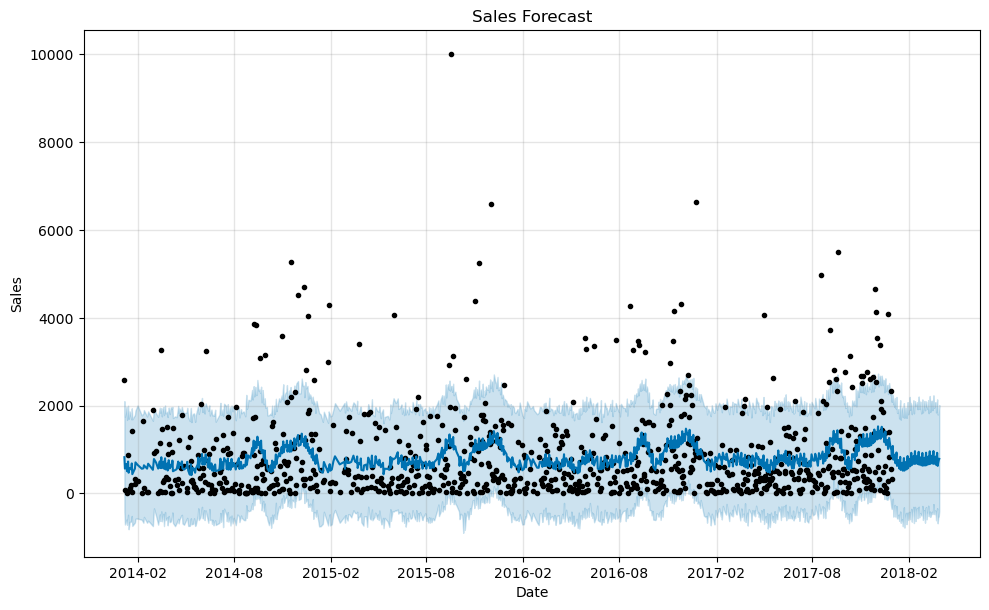

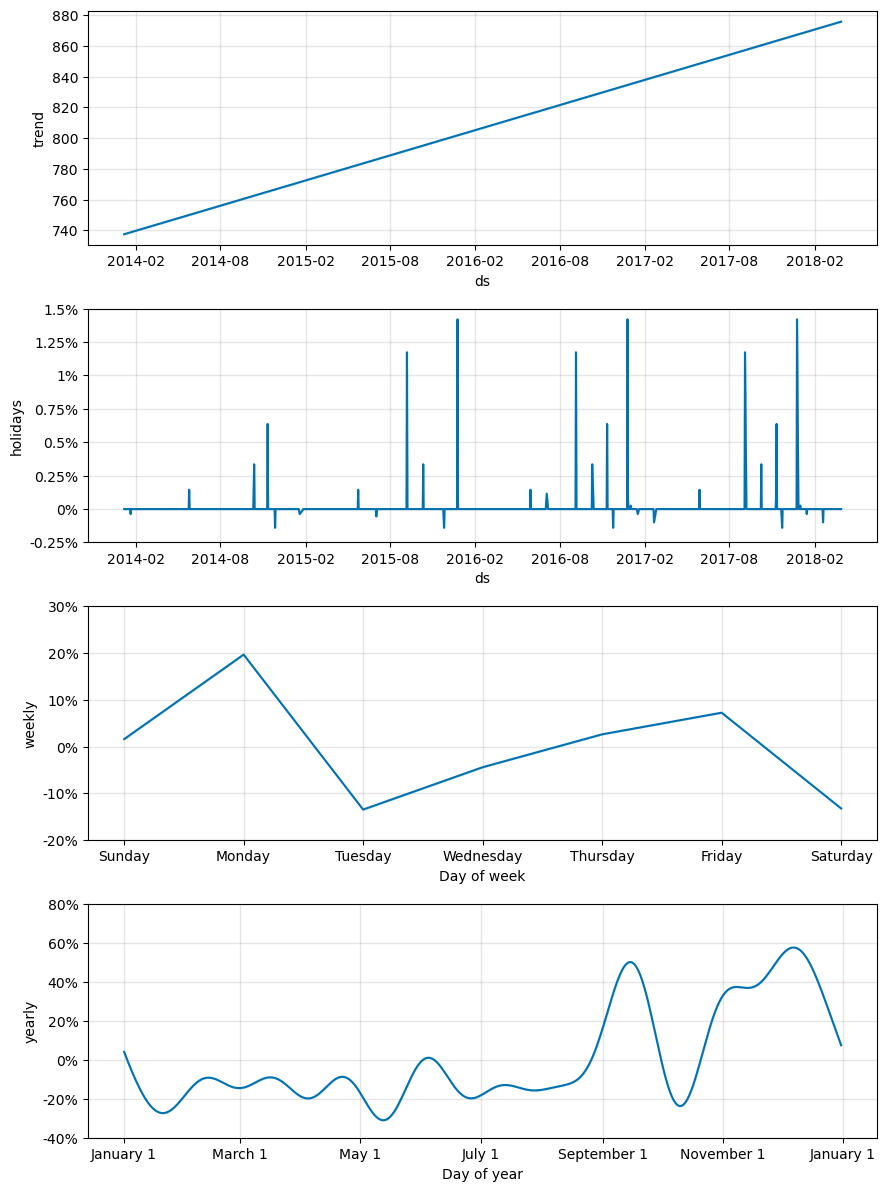

In [6]:
# Your code for plotting the forecast
plt.figure(figsize=(12, 6))
fig = model.plot(forecast)
plt.title('Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

# Your code for plotting the components
fig2 = model.plot_components(forecast)
plt.show()

**💡 Tip:** The components plot shows separate graphs for trend, weekly seasonality, yearly seasonality, and holidays, helping you identify which factors have the biggest impact on sales.

**⚙️ Test Your Work:**

- Two plots should appear: the forecast with confidence intervals and the components breakdown
- Verify that the components include trend, weekly seasonality, yearly seasonality, and holidays

## Task 6: Evaluate Forecast Performance
**Context:** To determine the reliability of forecasts, businesses need to measure how well the model performs on historical data.

**Steps:**

1. Filter the forecast to include only dates that exist in your original data.


2. Merge the actual sales with predicted values based on the date.


3. Calculate error metrics:

    - Mean Absolute Error (MAE)
    - Root Mean Squared Error (RMSE)
    - Mean Absolute Percentage Error (MAPE)


4. Interpret the results in the context of the business.

In [7]:
# Your code for filtering historical forecast data
historical_forecast = forecast[forecast['ds'].isin(daily_sales['ds'])]
historical_data = daily_sales.copy()


# Your code for merging actual and predicted values
evaluation = pd.merge(historical_data,
                      historical_forecast[['ds', 'yhat']],
                      on='ds',
                      how='left')

# Your code for calculating error metrics
mae = mean_absolute_error(evaluation['y'], evaluation['yhat'])
rmse = np.sqrt(mean_squared_error(evaluation['y'], evaluation['yhat']))
# MAPE calculation: handle division by zero if y can be 0
mape = np.mean(np.abs((evaluation['y'] - evaluation['yhat']) / evaluation['y'].replace(0, np.nan))) * 100 # Replace 0 with NaN for MAPE calc

# Print the metrics
print(f"\nModel Performance Metrics:")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


Model Performance Metrics:
MAE: $669.51
RMSE: $967.48
MAPE: 788.71%


**💡 Tip:** MAPE is particularly useful as it shows the average percentage difference between forecasted and actual values, making it intuitive for stakeholders.

**⚙️ Test Your Work:**

- You should have numeric values for MAE, RMSE, and MAPE
- MAE and RMSE are in the same units as your sales data
- MAPE should be expressed as a percentage

## ✅ Success Checklist
- Time series data is properly prepared with 'ds' and 'y' columns
- Visualizations clearly show the original time series and forecast
- Prophet model is configured with appropriate seasonality settings and holidays
- Forecast extends the appropriate number of periods into the future
- Component plots show trend, seasonality, and holiday effects
- Error metrics are calculated and interpreted
- Program runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Prophet installation fails

**Solution:** Use `!pip install prophet` or try the conda installation `conda install -c conda-forge prophet`

**Problem:** "No module named 'prophet'" error

**Solution:** Some environments require importing as `from fbprophet import Prophet` instead of `from prophet import Prophet`

**Problem:** Model performance is poor with high error metrics

**Solution:** Try adjusting seasonality parameters, add additional regressors, or experiment with different changepoint settings

**Problem:** Strange seasonal patterns in the forecast

**Solution:** Check if `seasonality_mode` is set appropriately ('additive' vs 'multiplicative') based on your data patterns

## 🔑 Key Points
- Prophet works best when data is properly prepared with clear date and target value columns
- Including relevant holidays and seasonal patterns significantly improves retail forecasting accuracy
- Component plots help explain the forecasts to business stakeholders by breaking down trends and seasonality
- Error metrics provide an objective measure of forecast reliability
- Forecasting enables proactive business decisions for inventory management and resource allocation

## 💻 Exemplar Solution

<details>

<summary><strong>Click HERE to see an exemplar solution</strong></summary>    
    
```python
# Import necessary libraries
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
data = pd.read_csv('stores_sales_forecasting.csv', encoding='latin-1')
print(data.head())
print("Dataset shape:", data.shape)

# Task 1: Prepare Time Series Data for Prophet
# Convert date columns to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

# Aggregate sales by date for time series forecasting
daily_sales = data.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['ds', 'y']  # Rename for Prophet compatibility

# Examine the aggregated data
print("\nDaily sales data:")
print(daily_sales.head())

# Task 2: Visualize the Time Series Data
# Visualize the time series
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['ds'], daily_sales['y'])
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# Task 3: Build and Fit the Prophet Model
# Create and fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # Retail often has multiplicative seasonality

    # --- Additional Parameters You Can Add/Adjust ---

    # 1. changepoint_prior_scale:
    # Controls the flexibility of the trend. A higher value allows the trend
    # to change more abruptly, a lower value makes it smoother.
    # Default is 0.05. For retail, sudden shifts due to marketing campaigns,
    # economic changes, or new product launches might occur.
    changepoint_prior_scale=0.01, # Experiment with values like 0.005, 0.1, 0.5

    # 2. seasonality_prior_scale:
    # Controls the strength of the seasonality components (yearly, weekly, etc.).
    # A higher value means stronger seasonality. Default is 10.0.
    # Retail sales often have very strong seasonality around holidays, so
    # increasing this might help capture those patterns more robustly.
    seasonality_prior_scale=12.0, # Experiment with values like 5.0, 20.0

    # 3. holidays_prior_scale:
    # Controls the strength of holiday effects. Default is 10.0.
    # If holidays have a particularly significant impact on your sales beyond
    # regular seasonality, increasing this value can give them more weight.
    holidays_prior_scale=10.0, # Experiment with values like 5.0, 20.0

    # 4. interval_width:
    # Adjusts the width of the uncertainty intervals (e.g., yhat_lower, yhat_upper).
    # Default is 0.80 (for 80% confidence interval). Use 0.95 for 95% confidence.
    # This affects the visualization of uncertainty, not the forecast itself.
    interval_width=0.80, # Set to 0.95 for wider, 95% confidence intervals

    # 5. growth:
    # Specifies the trend model. Default is 'linear'. Another option is 'logistic'
    # for saturating growth. 'logistic' requires adding 'cap' and 'floor' columns
    # to your DataFrame to define the maximum/minimum possible values for y.
    # growth='linear' # Usually fine for most sales data unless saturation is expected

    # 6. daily_seasonality:
    # You already have this set to False. Keep it unless your data truly has
    # clear intra-day patterns (e.g., hourly sales).
    # daily_seasonality=False
)

# Add US holidays
model.add_country_holidays(country_name='US')

# Fit the model
model.fit(daily_sales)

# Task 4: Generate Future Forecasts
# Generate future forecasts (next 90 days)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Print forecast for the next few periods
print("\nForecast for the next few days:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))

# Task 5: Visualize and Interpret the Forecast
# Visualize the forecast
plt.figure(figsize=(12, 6))
fig = model.plot(forecast)
plt.title('Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

# Visualize forecast components
fig2 = model.plot_components(forecast)
plt.show()

# Task 6: Evaluate Forecast Performance
# Calculate metrics on the historical period
historical_forecast = forecast[forecast['ds'].isin(daily_sales['ds'])]
historical_data = daily_sales.copy()

# Merge actual and predicted values
evaluation = pd.merge(historical_data,
                      historical_forecast[['ds', 'yhat']],
                      on='ds',
                      how='left')

# Calculate error metrics
mae = mean_absolute_error(evaluation['y'], evaluation['yhat'])
rmse = np.sqrt(mean_squared_error(evaluation['y'], evaluation['yhat']))
# MAPE calculation: handle division by zero if y can be 0
mape = np.mean(np.abs((evaluation['y'] - evaluation['yhat']) / evaluation['y'].replace(0, np.nan))) * 100 # Replace 0 with NaN for MAPE calc

print(f"\nModel Performance Metrics:")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
    
```    